<a href="https://colab.research.google.com/github/Deepvejpara/Income_Classifier/blob/main/DL_PR2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Data Loading, Cleaning & Exploratory Data Analysis

### 1.1 Load and inspect the dataset

In [1]:
!git clone https://github.com/Deepvejpara/Income_Classifier.git

Cloning into 'Income_Classifier'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 18 (delta 3), reused 9 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 625.58 KiB | 4.60 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [2]:
import os

In [3]:
# Changing dir to edit inside folder
os.chdir('/content/Income_Classifier')

In [4]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('dataset/adult.csv')

In [6]:
df.shape

(48842, 15)

In [7]:
print(df.dtypes)

age                 int64
workclass          object
fnlwgt              int64
education          object
educational-num     int64
marital-status     object
occupation         object
relationship       object
race               object
gender             object
capital-gain        int64
capital-loss        int64
hours-per-week      int64
native-country     object
income             object
dtype: object


In [8]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [9]:
# Collecting Categorical columns in cols
cols = df.select_dtypes('object').columns
cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

In [10]:
# Removing extra Space
for col in cols:
  df[col] = df[col].str.strip()

### 1.2 Handle missing values

In [11]:
df.replace('?', np.nan, inplace=True)

In [12]:
print(df.isnull().sum())

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [13]:
df.dropna(inplace=True)

**Justification for Dropping Missing Values over Imputation:**

The missing values in this dataset (originally encoded as `?`) exist exclusively in categorical columns with many unique categories: `workclass` (~2,799 missing), `occupation` (~2,809 missing), and `native-country` (~857 missing).

Using mode imputation (replacing missing values with the most frequent category) would disproportionately inflate the most common category, introducing unnatural bias into the dataset. Because dropping the rows with any missing value only removes approximately 2,399 records—leaving us with a robust dataset of ~45,222 clean records—dropping them is a statistically safer and cleaner approach than imputation for this specific dataset.

### 1.3 Drop redundant columns

In [14]:
df.drop(columns=['fnlwgt','education'], inplace=True)

In [15]:
df.shape

(45222, 13)

### 1.4 Encode the target

In [16]:
df['income'] = (df['income'] == '>50K').astype(int)

In [17]:
df['income'].value_counts()

,count
income,
0,34014
1,11208


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

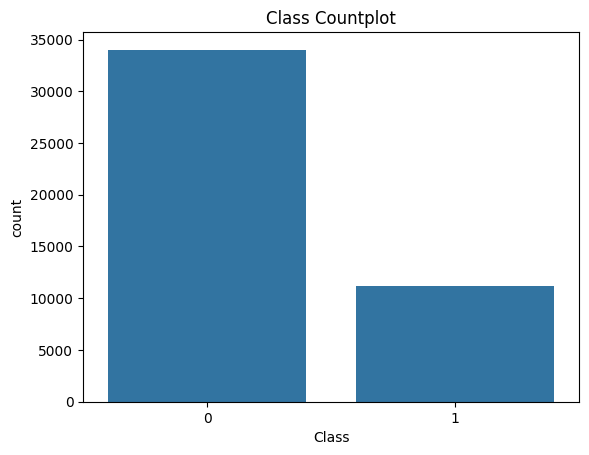

In [21]:
sns.countplot(x=df['income'])
plt.xlabel('Class')
plt.title('Class Countplot')
plt.show()

**Why Accuracy Alone is Misleading:**

As shown in the target distribution, there is a significant ~3:1 class imbalance, with approximately 75% of individuals earning `<=50K` (Class 0) and only 25% earning `>50K` (Class 1)[cite: 1].

Because of this imbalance, overall accuracy is a misleading metric. A naive model that simply predicts '0' for every single person would automatically achieve ~75% accuracy without actually learning anything useful[cite: 1]. Therefore, to properly evaluate how well our model identifies high earners, we will track F1-score, Precision, and Recall alongside accuracy throughout the rest of this project[cite: 1].

### 1.5 Exploratory visualisations

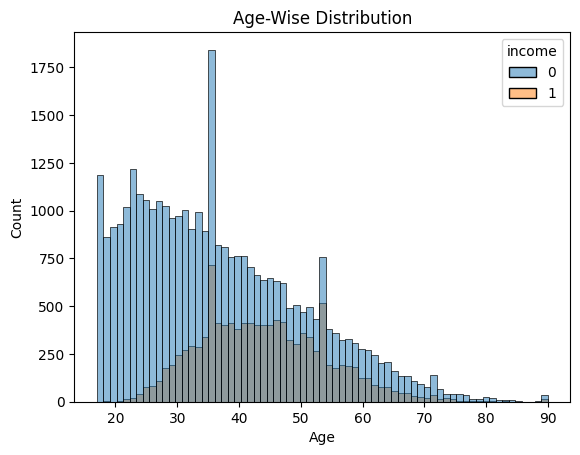

In [24]:
sns.histplot(x=df['age'],hue=df['income'])
plt.title('Age-Wise Distribution')
plt.xlabel('Age')
plt.show()

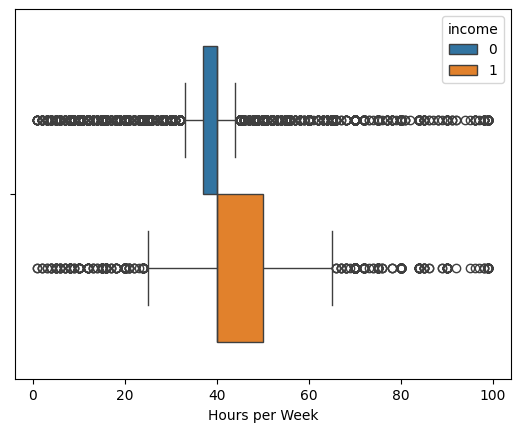

In [30]:
sns.boxplot(x=df['hours-per-week'],hue=df['income'])
plt.xlabel('Hours per Week')
plt.show()

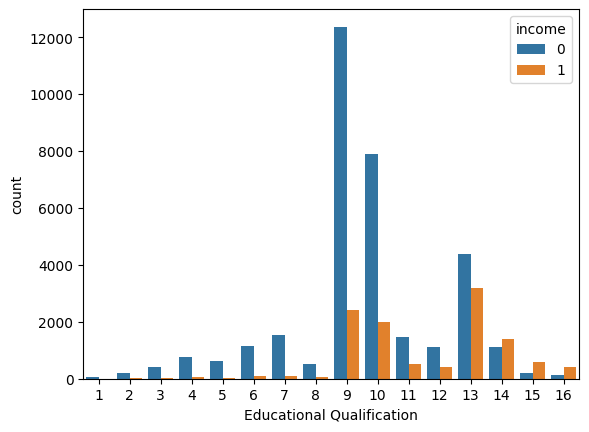

In [32]:
sns.countplot(x=df['educational-num'],hue=df['income'])
plt.xlabel('Educational Qualification')
plt.show()

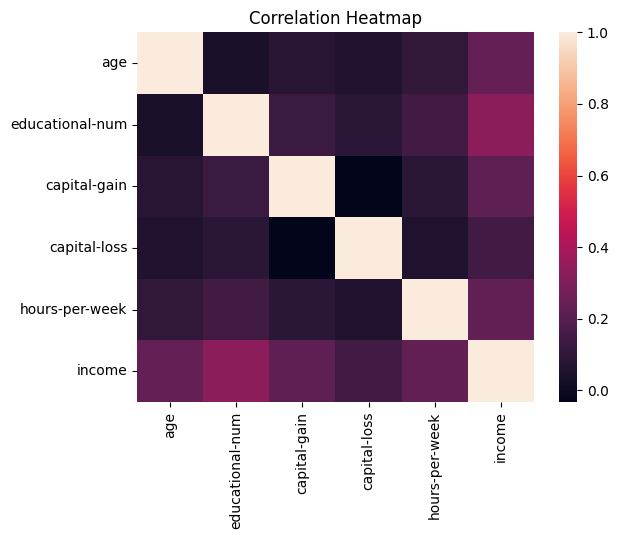

In [37]:
sns.heatmap(data=df.corr(numeric_only=True))
plt.title('Correlation Heatmap')
plt.show()

**1. Age Distribution by Income**

The histogram (image_f4dd7b.png) reveals that individuals earning `<=50K` (Class 0) are heavily concentrated in their early 20s and early 30s. Conversely, the proportion of individuals earning `>50K` (Class 1) increases significantly in the middle-age brackets (roughly mid-30s to mid-50s). This indicates that age—likely acting as a proxy for career experience, seniority, and promotions—is a strong positive predictor for higher income.

**2. Hours per Week Boxplot**

The boxplot (image_f52efa.png) shows that the median working hours for those earning `<=50K` sits strictly at 40 hours per week, with a massive spread of outliers on the lower end (part-time work). For individuals earning `>50K`, the median and interquartile range shift higher (closer to 45–50 hours). This pattern reveals that working standard or sub-standard hours is heavily associated with lower income, while working overtime or longer hours is a strong predictor of crossing the $50K threshold.

**3. Educational Qualification Countplot**

The countplot (image_f52f1a.png) clearly demonstrates that higher numeric education levels strongly correlate with high income. Lower education levels (particularly level 9, which typically represents a High School graduate) are overwhelmingly dominated by the `<=50K` category. As `education.num` increases to 13 (Bachelors) and above, the ratio of high-earners increases sharply. At the highest levels (15 and 16, representing professional and doctorate degrees), the number of high-earners actually exceeds the low-earners.

**4. Correlation Heatmap**

The numeric correlation heatmap (image_f52f3c.png) mathematically confirms the visual findings from the previous plots. `educational-num` displays the strongest positive correlation with the `income` target (represented by the brighter/lighter color block intersecting the two). `age` and `hours-per-week` also show meaningful positive correlations with income, confirming that older, highly educated individuals who work more hours have the highest probability of earning >50K.

### 1.6 Encode categoricals & scale numerics

In [38]:
X = df.drop('income', axis=1)
y = df['income']

In [41]:
X = pd.get_dummies(X, drop_first=True).astype(int)

In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()

In [51]:
num_cols = ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']

In [52]:
X[num_cols] = scaler.fit_transform(X[num_cols])

In [55]:
# Exporting Scaler model for Future use
import pickle

In [56]:
with open('models/scaler_model','wb') as file:
  pickle.dump(scaler,file)

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [60]:
print(X_train.shape)
print(X_test.shape)

(36177, 80)
(9045, 80)


In [62]:
print(y_train.shape)
print(y_test.shape)

(36177,)
(9045,)


In [64]:
print(y_train.value_counts()/len(y_train))
print(y_test.value_counts()/len(y_test))

income
0    0.752163
1    0.247837
Name: count, dtype: float64
income
0    0.752128
1    0.247872
Name: count, dtype: float64


We use Stratify to ditribute same ratio of Classes for train and test